# student visits to the Museum

**HOW TO USE THIS JUPYTER NOTEBOOK:** highlight the cell by clicking on it. You should see a green or blue box surround it. Then hold the Shift key and press Enter. You should see the highlight box move on to the next cell, and it will print or plot whatever the code says to do.
Try it here. Click on the gray text box below to highlight the cell, then hold Shift and press Enter.

In [24]:
print("Hello world!")

Hello world!


If it says **Hello world!** to you below the gray cell, it worked!

## Import statements, classes, and methods. 
Run these (Shift, Enter) then keep going. They shouldn't spit anything out at you. If they do, tell Abbie.

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
import ipywidgets as widgets
import traitlets
import datetime
from IPython.display import display
from tkinter import Tk, filedialog

In [26]:
xlsx_file = "./students.xlsx"
df = pd.read_excel(xlsx_file, engine='openpyxl')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066 entries, 0 to 3065
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Sales Order Item\Date added    3066 non-null   datetime64[ns]
 1   Sales Order Item\Date changed  3066 non-null   datetime64[ns]
 2   Sales Order Item\Quantity      3066 non-null   int64         
 3   QUERYRECID                     3066 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 95.9+ KB
None


/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [27]:
df.drop(columns={'QUERYRECID', 'Sales Order Item\\Date changed'}, axis=1, inplace=True)
df = df.rename(columns={'Sales Order Item\\Date added': 'DateTime', 'Sales Order Item\\Quantity': 'Quantity'})
df['Day'] = [j.strftime('%a') for j in df['DateTime']]
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066 entries, 0 to 3065
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  3066 non-null   datetime64[ns]
 1   Quantity  3066 non-null   int64         
 2   Day       3066 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 72.0+ KB
None


In [28]:
df['Time'] = [j.strftime('%-H:%M') for j in df['DateTime']]
df['Date'] = [j.strftime('%Y-%m-%d') for j in df['DateTime']]
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066 entries, 0 to 3065
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  3066 non-null   datetime64[ns]
 1   Quantity  3066 non-null   int64         
 2   Day       3066 non-null   object        
 3   Time      3066 non-null   object        
 4   Date      3066 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 119.9+ KB
None


In [29]:
def which_exhibition(visit_date):
    if visit_date <= "2023-02-26":
        return "1.5 Celsius"
    elif visit_date >= "2023-04-19" and visit_date <= "2023-11-12":
        return "Knowing Nature"
    elif visit_date >= "2024-01-05":
        return "Food Fight"
    else:
        return "No MG"

In [30]:
df['Exhibition'] = [which_exhibition(j) for j in df['Date']]

In [31]:
display(df)

,DateTime,Quantity,Day,Time,Date,Exhibition
0,2022-09-06 10:54:14.187,1,Tue,10:54,2022-09-06,1.5 Celsius
1,2022-09-06 13:49:55.070,2,Tue,13:49,2022-09-06,1.5 Celsius
2,2022-09-06 14:47:58.597,1,Tue,14:47,2022-09-06,1.5 Celsius
3,2022-09-06 15:04:45.377,1,Tue,15:04,2022-09-06,1.5 Celsius
4,2022-09-06 16:16:11.343,3,Tue,16:16,2022-09-06,1.5 Celsius
...,...,...,...,...,...,...
3061,2024-06-29 13:12:00.543,2,Sat,13:12,2024-06-29,Food Fight
3062,2024-06-29 14:03:58.520,1,Sat,14:03,2024-06-29,Food Fight
3063,2024-06-29 14:04:00.433,1,Sat,14:04,2024-06-29,Food Fight
3064,2024-06-29 15:00:17.023,1,Sat,15:00,2024-06-29,Food Fight


DatetimeIndex(['2022-10-01', '2023-01-01', '2023-04-01', '2023-07-01',
               '2023-10-01', '2024-01-01', '2024-04-01', '2024-07-01'],
              dtype='datetime64[ns]', freq='QS-JAN')


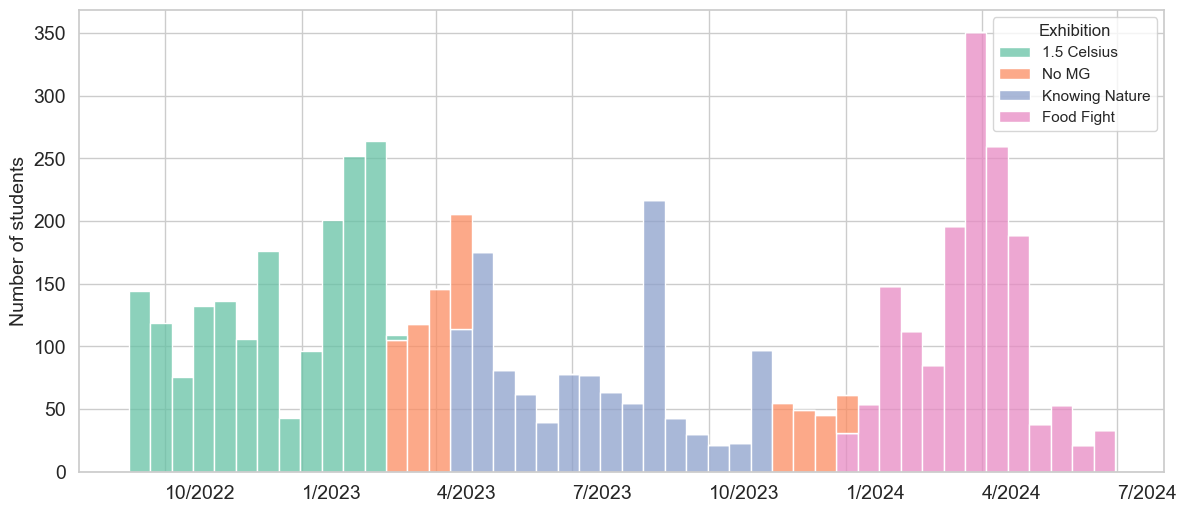

In [32]:
#x_dates = pd.date_range(start='2022-09-01', end='2024-07-01', freq='MS', inclusive='both')
x_dates = pd.date_range(start='2022-09-01', end='2024-07-01', freq='QS', inclusive='both')

print(x_dates)
fig, ax = plt.subplots(figsize=(14,6))
fig = sns.histplot(data=df, x='DateTime', hue='Exhibition', weights="Quantity", bins=46, multiple='stack', 
                   palette="Set2",)
ax.set_xticks(x_dates, labels=x_dates.strftime('%-m/%Y'), horizontalalignment='left')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel("")
ax.set_ylabel("Number of students")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("timeline_scatter.png",bbox_inches='tight')
plt.show()

In [33]:
df['NumTime'] = [int(j.strftime('%-H%M')) for j in df['DateTime']]
# astype("int64")
print(df['NumTime'])

0       1054
1       1349
2       1447
3       1504
4       1616
        ... 
3061    1312
3062    1403
3063    1404
3064    1500
3065    1500
Name: NumTime, Length: 3066, dtype: int64


/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_40023/1510479036.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hour_labels)


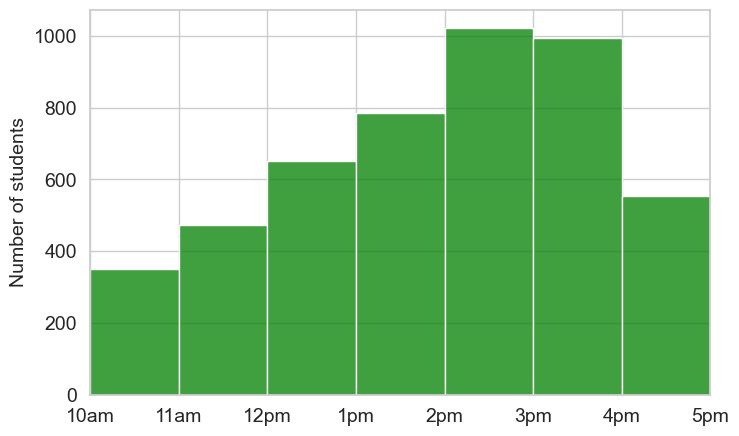

In [34]:
hours=(1000,1100,1200,1300,1400,1500,1600,1700)
hour_labels=("10am","11am","12pm","1pm","2pm","3pm","4pm","5pm")
fig, ax = plt.subplots(figsize=(8,5))
fig = sns.histplot(data=df, x='NumTime', weights='Quantity', bins=hours, color='green')
ax.set_xlim(1000, 1700)
ax.set_xticklabels(hour_labels)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel("")
ax.set_ylabel("Number of students")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("student_time_bar.png", bbox_inches='tight')
plt.show()

In [35]:
day_cats = ['Tue', 'Wed', 'Thu', 'Fri', 'Sat']
df['Day'] = pd.Categorical(df['Day'], categories=day_cats, ordered=True)

In [36]:
df.groupby('Day', observed=False, dropna=True)['Quantity'].sum()

Day
Tue     725
Wed     875
Thu     621
Fri    1180
Sat    1626
Name: Quantity, dtype: int64

/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_40023/3044966089.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(fig.get_xticklabels())


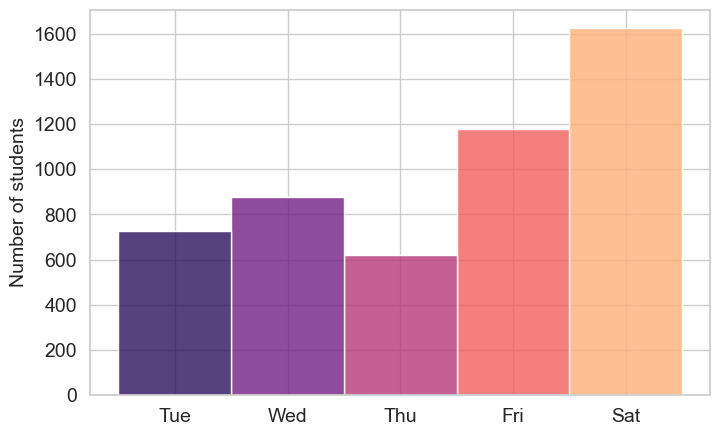

In [37]:
fig, ax = plt.subplots(figsize=(8,5))
fig = sns.histplot(df, x='Day', hue='Day', weights='Quantity', palette='magma', alpha=0.8, legend=False)
fig.set_xticklabels(fig.get_xticklabels())
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel("")
ax.set_ylabel("Number of students")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("student_day_bar.png", bbox_inches='tight')
plt.show()

/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_40023/1757126314.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(fig.get_xticklabels(), rotation=345)
/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_40023/1757126314.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hour_labels)


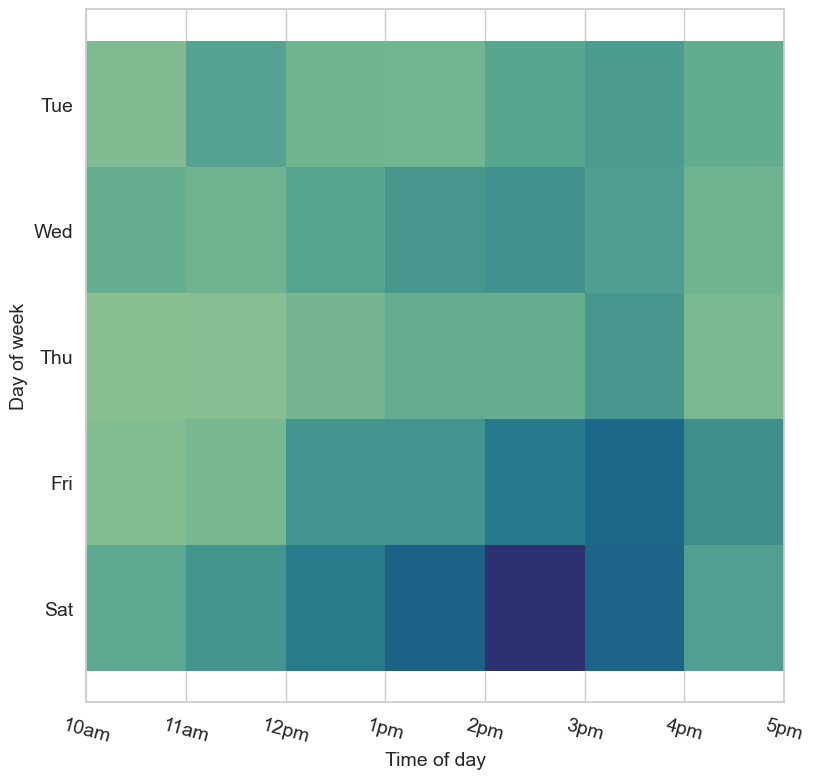

In [38]:
fig, ax = plt.subplots(figsize=(9,9))
fig = sns.histplot(df, x='NumTime', y='Day', weights='Quantity', bins=hours, cmap='crest')
fig.set_xticklabels(fig.get_xticklabels(), rotation=345)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlim(1000, 1700)
ax.set_xticklabels(hour_labels)
ax.set_xlabel("Time of day")
ax.set_ylabel("Day of week")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("student_daytime_2D.png", bbox_inches='tight')
plt.show()